In [107]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.model_selection import GridSearchCV

import pickle

In [108]:
df = pd.read_excel("insurance.xlsm")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [109]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [110]:
# Checking for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [111]:
# Checking for duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [112]:
#checking unique values in df
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

age: [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
sex: ['female' 'male']
bmi: [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75  28.975 31.35  33.915 28.785 28.3   37.4   17.765

<Axes: xlabel='charges', ylabel='Count'>

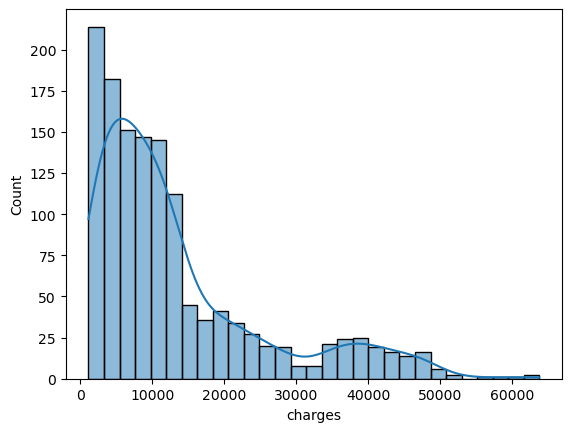

In [113]:
# Target variable distribution
sns.histplot(df['charges'], kde=True)

In [114]:
# defining categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns 
numerical_cols = df.select_dtypes(include=[np.number]).columns  

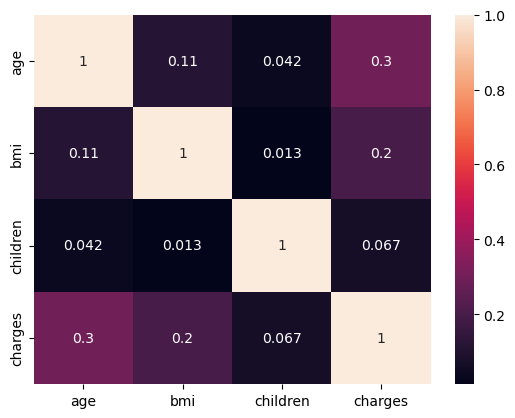

In [115]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

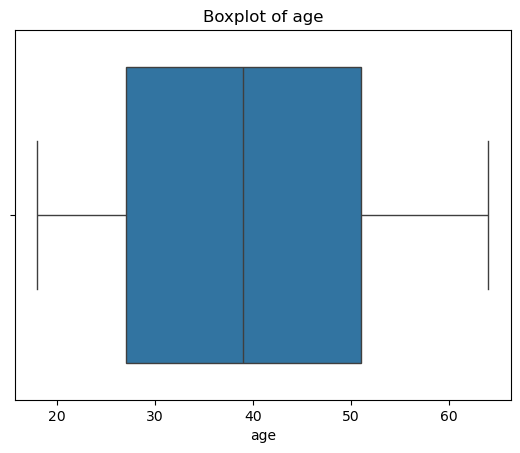

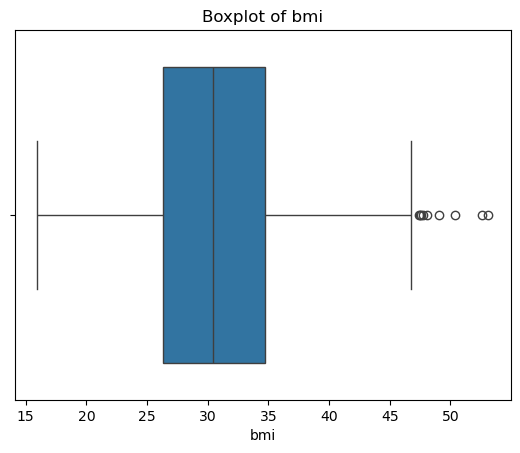

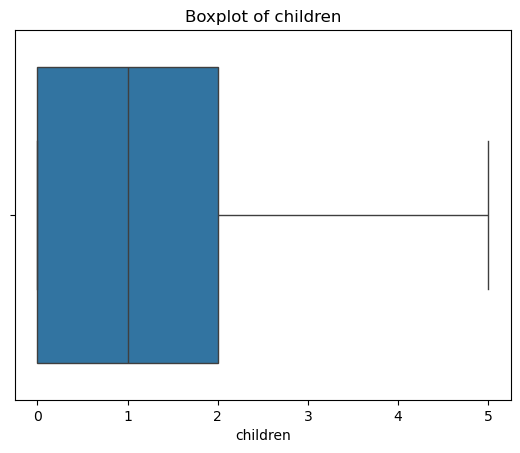

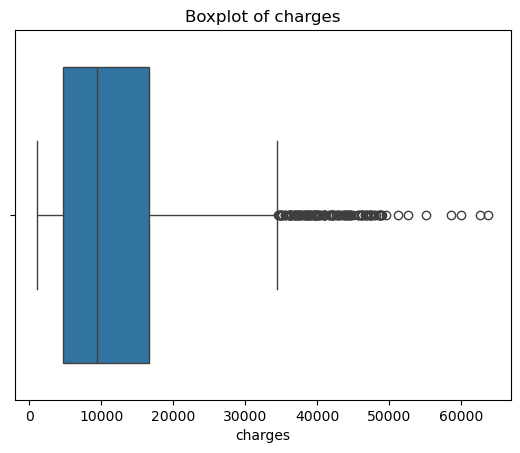

In [116]:
# cheking outliers
for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()  

In [117]:
#checking skeness of data
for col in numerical_cols:
    print(f"{col} skewness: {df[col].skew()}")
    

age skewness: 0.054780773126998195
bmi skewness: 0.28391419385321137
children skewness: 0.9374206440474123
charges skewness: 1.5153909108403483


In [118]:
# converting categorical variables to numerical using mapping for sex and regsmoker and onehot encoding for region

df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})  
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [119]:
# defining features and target variable

X = df.drop('charges', axis=1)  
y = df['charges']

# log-transormation of numerical features to reduce skewness
for col in numerical_cols:
    if col != 'charges':  
        X[col] = np.log1p(X[col])   
        
# splitting data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [120]:
# caping for outliers using IQR method
for col in numerical_cols:      
    if col != 'charges':  
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        X_train[col] = np.where(X_train[col] < lower_bound, lower_bound, X_train[col])
        X_train[col] = np.where(X_train[col] > upper_bound, upper_bound, X_train[col])

In [121]:
# definig models
models = {

    "Linear Regression":LinearRegression(),

    "Decision Tree":DecisionTreeRegressor(),

    "Random Forest":RandomForestRegressor(),

    "SVR":SVR(),

    "KNN":KNeighborsRegressor(),

    "Gradient Boosting":GradientBoostingRegressor()

}

def adjusted_r2(r2,n,p):
    
    adj_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)
    
    return adj_r2

def evaluate_model(model,X_train,X_test,y_train,y_test):

    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train,y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test,y_test_pred))

    # R2
    train_r2 = r2_score(y_train,y_train_pred)
    test_r2 = r2_score(y_test,y_test_pred)

    # Adjusted R2
    n_train = X_train.shape[0]
    n_test = X_test.shape[0]
    p = X_train.shape[1]

    train_adj_r2 = adjusted_r2(train_r2,n_train,p)
    test_adj_r2 = adjusted_r2(test_r2,n_test,p)

    return train_rmse,test_rmse,train_r2,test_r2,train_adj_r2,test_adj_r2

In [ ]:

# evaluate and compare models
results = []

for name,model in models.items():

    train_rmse,test_rmse,train_r2,test_r2,train_adj_r2,test_adj_r2 = evaluate_model(
        model,X_train,X_test,y_train,y_test
    )

    overfit = "Yes" if (train_adj_r2 - test_adj_r2) > 0.2 else "No"

    results.append([
        name,
        train_rmse,
        test_rmse,
        train_adj_r2,
        test_adj_r2,
        overfit
    ])

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train RMSE",
        "Test RMSE",
        "Train Adjusted R2",
        "Test Adjusted R2",
        "Overfitting"
    ]
)

comparison_df

,Model,Train RMSE,Test RMSE,Train Adjusted R2,Test Adjusted R2,Overfitting
0,Linear Regression,6158.889882,6010.475286,0.720861,0.797331,No
1,Decision Tree,0.000000,6220.448066,1.000000,0.782923,Yes
2,Random Forest,1852.295955,4674.580069,0.974751,0.877410,No
3,SVR,12276.480538,14433.215523,-0.109081,-0.168681,No
4,KNN,5097.899789,6584.136119,0.808752,0.756798,No
5,Gradient Boosting,3852.413107,4256.666351,0.890785,0.898350,No


In [123]:
# we can see that Random Forest and Gradient Boosting have the good performances, 
# but Random Forest is slightly better and seems to be slightly overfitting, 
# so we will choose it for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


grid = GridSearchCV(
RandomForestRegressor(),
param_grid,
cv=5,
scoring="r2"
)

grid.fit(X_train,y_train)

grid.best_params_

#Train best model

best_model = grid.best_estimator_

best_model.fit(X_train,y_train)
# Evaluate best model
y_test_pred = best_model.predict(X_test)

# Calculate metrics
test_rmse = np.sqrt(mean_squared_error(y_test,y_test_pred)) 
test_r2 = r2_score(y_test,y_test_pred)
n_test = X_test.shape[0]
p = X_test.shape[1]
test_adj_r2 = adjusted_r2(test_r2,n_test,p)
print(f"Test RMSE: {test_rmse}")
print(f"Test R2: {test_r2}")    
print(f"Test Adjusted R2: {test_adj_r2}")

#update comparison df with best model results

comparison_df.loc[comparison_df["Model"]=="Random Forest",
                  ["Train RMSE","Test RMSE","Train Adjusted R2","Test Adjusted R2","Overfitting"]
                 ] = [
                     train_rmse,
                     test_rmse,
                     train_adj_r2,
                     test_adj_r2,
                     overfit
                 ]
comparison_df

Test RMSE: 4501.962751043283
Test R2: 0.88970340261942
Test Adjusted R2: 0.886296557912684


,Model,Train RMSE,Test RMSE,Train Adjusted R2,Test Adjusted R2,Overfitting
0,Linear Regression,6158.889882,6010.475286,0.720861,0.797331,No
1,Decision Tree,0.000000,6220.448066,1.000000,0.782923,Yes
2,Random Forest,3852.413107,4501.962751,0.890785,0.886297,No
3,SVR,12276.480538,14433.215523,-0.109081,-0.168681,No
4,KNN,5097.899789,6584.136119,0.808752,0.756798,No
5,Gradient Boosting,3852.413107,4256.666351,0.890785,0.898350,No


In [124]:
# selecting best model based on updated comparison df
best_model_name = comparison_df.sort_values(by="Test Adjusted R2", ascending=False).iloc[0]["Model"]
print(f"Best model: {best_model_name}")
comparison_df
# appending best model to comparison df
# best_model_row = comparison_df[comparison_df["Model"]==best_model_name] 
# comparison_df = pd.concat([comparison_df,best_model_row], ignore_index=True)
# comparison_df

Best model: Gradient Boosting


,Model,Train RMSE,Test RMSE,Train Adjusted R2,Test Adjusted R2,Overfitting
0,Linear Regression,6158.889882,6010.475286,0.720861,0.797331,No
1,Decision Tree,0.000000,6220.448066,1.000000,0.782923,Yes
2,Random Forest,3852.413107,4501.962751,0.890785,0.886297,No
3,SVR,12276.480538,14433.215523,-0.109081,-0.168681,No
4,KNN,5097.899789,6584.136119,0.808752,0.756798,No
5,Gradient Boosting,3852.413107,4256.666351,0.890785,0.898350,No


In [125]:
# saving best model using pickle
with open("best_model.pkl","wb") as f:
    pickle.dump(best_model,f)   

pickle.dump(X.columns.tolist(),open("model_features.pkl","wb"))
